In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
columns=['age','workclass','fnlwgt','education','education_num','martial_status','occupation'
        ,'relationship','race','sex','capital_gain','capital_loss','hours_per_week','native_country','income']

In [3]:
train=pd.read_csv("adult.data",names=columns,sep=",",skipinitialspace=True)

In [4]:
train.head(2)

,age,workclass,fnlwgt,education,education_num,martial_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K


In [5]:
test=pd.read_csv('adult.test',names=columns,sep=",",skipinitialspace=True)

In [6]:
test.head(2)

,age,workclass,fnlwgt,education,education_num,martial_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K.
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K.


In [7]:
test['income']=test['income'].str.replace(".","")

In [8]:
test.head(2)

,age,workclass,fnlwgt,education,education_num,martial_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K


In [9]:
df=pd.concat([train,test],ignore_index=True)

In [10]:
print(f"No of columns in the dataset = {df.shape[1]}")
print(f"No of rows in the dataset = {df.shape[0]}")

No of columns in the dataset = 15
No of rows in the dataset = 48842


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education_num   48842 non-null  int64 
 5   martial_status  48842 non-null  object
 6   occupation      48842 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital_gain    48842 non-null  int64 
 11  capital_loss    48842 non-null  int64 
 12  hours_per_week  48842 non-null  int64 
 13  native_country  48842 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [12]:
for i in df.select_dtypes(include='object'):
    print(i.upper())
    print(df[i].unique(),"\n")

WORKCLASS
['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' '?'
 'Self-emp-inc' 'Without-pay' 'Never-worked'] 

EDUCATION
['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th'] 

MARTIAL_STATUS
['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed'] 

OCCUPATION
['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' '?'
 'Protective-serv' 'Armed-Forces' 'Priv-house-serv'] 

RELATIONSHIP
['Not-in-family' 'Husband' 'Wife' 'Own-child' 'Unmarried' 'Other-relative'] 

RACE
['White' 'Black' 'Asian-Pac-Islander' 'Amer-Indian-Eskimo' 'Other'] 

SEX
['Male' 'Female'] 

NATIVE_COUNTRY
['United-States' 'Cuba' 'Jamaica' 'India' '?' 'Mexico' 'South'
 'Puerto-Rico' 'Honduras' 'Engl

In [13]:
df[['workclass','occupation','native_country']]=(df[['workclass','occupation','native_country']].replace("?",np.nan))

In [14]:
col=['workclass','occupation','native_country']
for i in col:
    df[i]=df[i].fillna(df[i].mode()[0])

In [15]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [16]:
df.head()

,age,workclass,fnlwgt,education,education_num,martial_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [17]:
df.drop_duplicates(inplace=True)

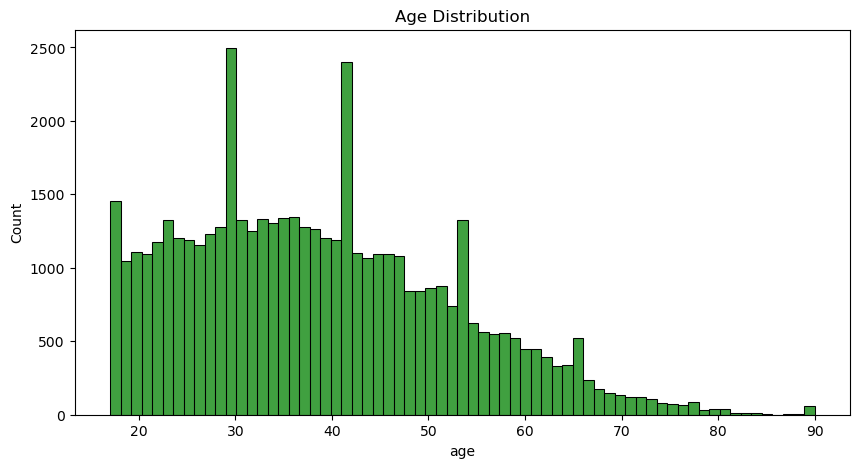

In [18]:
plt.figure(figsize=[10,5])
sns.histplot(data=df,x='age',color='green')
plt.title('Age Distribution')
plt.show()

In [19]:
print(f"Min age in the dataset = {df['age'].min()}")
print(f"Max age in the dataset = {df['age'].max()}")

Min age in the dataset = 17
Max age in the dataset = 90


In [20]:
df['education'].value_counts()

education
HS-grad         15770
Some-college    10862
Bachelors        8013
Masters          2656
Assoc-voc        2060
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           954
Prof-school       834
9th               756
12th              655
Doctorate         594
5th-6th           507
1st-4th           245
Preschool          81
Name: count, dtype: int64

In [21]:
print(f"Most common education level in the dataset is {df['education'].value_counts().idxmax()}")

Most common education level in the dataset is HS-grad


In [22]:
df['workclass'].value_counts()

workclass
Private             36654
Self-emp-not-inc     3861
Local-gov            3136
State-gov            1981
Self-emp-inc         1694
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

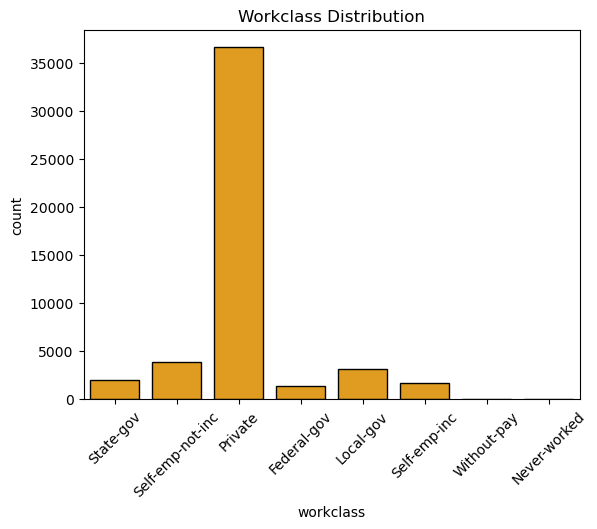

In [23]:
sns.countplot(data=df,x='workclass',color='orange',edgecolor='black')
plt.title('Workclass Distribution')
plt.xticks(rotation=45)
plt.show()

In [24]:
print(f"About {(df['workclass']=='Private').sum()*100/len(df):.2f}% peoples belongs to {df['workclass'].value_counts().idxmax()} class")

About 75.13% peoples belongs to Private class


In [25]:
edu_lvl_mapping=df.groupby('education')['education_num'].first().sort_values().reset_index()
#edu_lvl_mapping.columns=['eduation_lvl','education_num']
print("EDUCATION LEVELS")
edu_lvl_mapping


EDUCATION LEVELS


,education,education_num
0,Preschool,1
1,1st-4th,2
2,5th-6th,3
3,7th-8th,4
4,9th,5
5,10th,6
6,11th,7
7,12th,8
8,HS-grad,9
9,Some-college,10


In [26]:
df.head()

,age,workclass,fnlwgt,education,education_num,martial_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [27]:
df['martial_status'].value_counts()

martial_status
Married-civ-spouse       22366
Never-married            16081
Divorced                  6630
Separated                 1530
Widowed                   1518
Married-spouse-absent      627
Married-AF-spouse           37
Name: count, dtype: int64

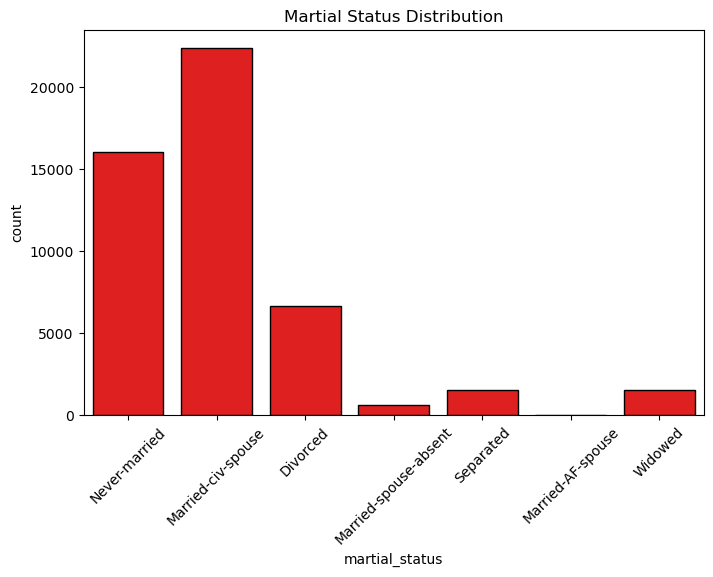

In [28]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x='martial_status',color='red',edgecolor='black')
plt.title('Martial Status Distribution')
plt.xticks(rotation=45)
plt.show()

In [29]:
print(f'Most Common Martial Staus of peoples are {df['martial_status'].value_counts().idxmax()} of about {(df["martial_status"]=='Married-civ-spouse').sum()*100/len(df):.2f}%')

Most Common Martial Staus of peoples are Married-civ-spouse of about 45.84%


In [30]:
occ=df['occupation'].value_counts()
occ.reset_index()

,occupation,count
0,Prof-specialty,8969
1,Craft-repair,6102
2,Exec-managerial,6082
3,Adm-clerical,5606
4,Sales,5501
5,Other-service,4919
6,Machine-op-inspct,3017
7,Transport-moving,2355
8,Handlers-cleaners,2071
9,Farming-fishing,1485


In [31]:
print(f"Most common occupation in the dataset is {df['occupation'].value_counts().idxmax()} of about {(df['occupation']=='Prof-specialty').sum()*100/len(df):.2f}%")

Most common occupation in the dataset is Prof-specialty of about 18.38%


In [32]:
df['relationship'].value_counts()

relationship
Husband           19703
Not-in-family     12557
Own-child          7568
Unmarried          5124
Wife               2331
Other-relative     1506
Name: count, dtype: int64

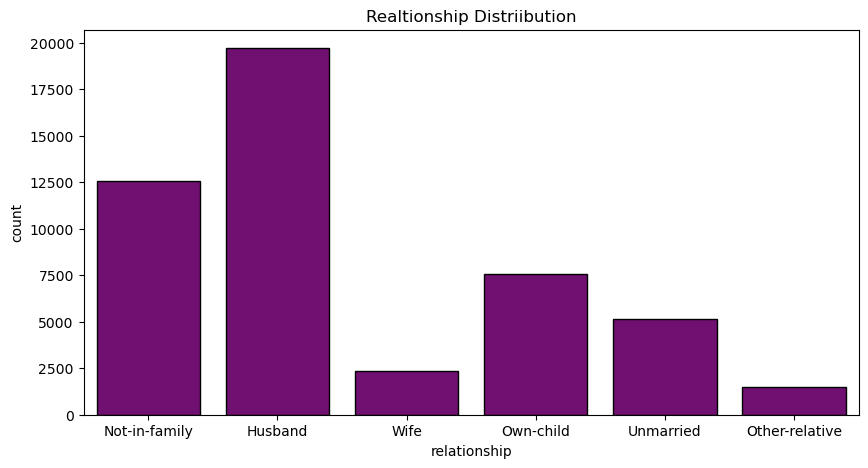

In [33]:
plt.figure(figsize=(10,5))
sns.countplot(data=df,x='relationship',color='purple',edgecolor='black')
plt.title('Realtionship Distriibution')
plt.show()

In [34]:
print(f"About {(df['relationship']=='Husband').sum()*100/len(df):.2f}% Individuals in the dataset have the relationship status of Husband")

About 40.38% Individuals in the dataset have the relationship status of Husband


In [35]:
race_count=df['race'].value_counts()
race_count.reset_index()

,race,count
0,White,41713
1,Black,4683
2,Asian-Pac-Islander,1517
3,Amer-Indian-Eskimo,470
4,Other,406


In [36]:
print(f"Most Individuals Belongs to the {race_count.idxmax()} race of about {(df['race']=='White').sum()*100/len(df):.2f}%")

Most Individuals Belongs to the White race of about 85.50%


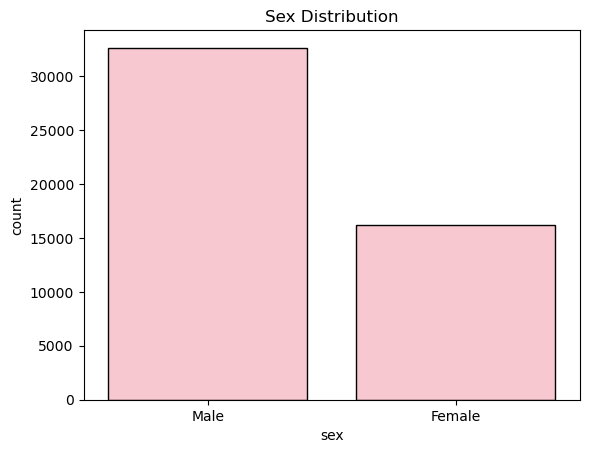

In [37]:
sns.countplot(data=df,x='sex',color='pink',edgecolor='black')
plt.title('Sex Distribution')
plt.show()

In [38]:
print(f"About {(df['sex']=='Male').sum()*100/len(df):.2f}% of individuals are Male")

About 66.85% of individuals are Male


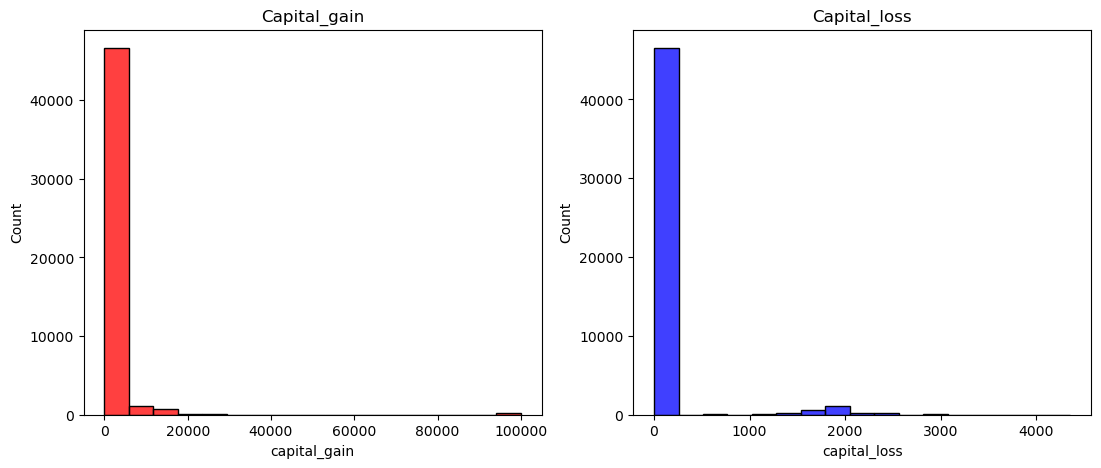

In [39]:
fig,ax=plt.subplots(1,2,figsize=(13,5))
sns.histplot(data=df,x='capital_gain',ax=ax[0],color='red')
ax[0].set_title('Capital_gain')
sns.histplot(data=df,x='capital_loss',ax=ax[1],color='blue')
ax[1].set_title('Capital_loss')
plt.show()

In [40]:
print(f"About {((df['capital_gain']==0)&(df['capital_loss']==0)).sum()*100/len(df):.2f}% of peoples have neither capital gain nor capital loss")

About 87.05% of peoples have neither capital gain nor capital loss


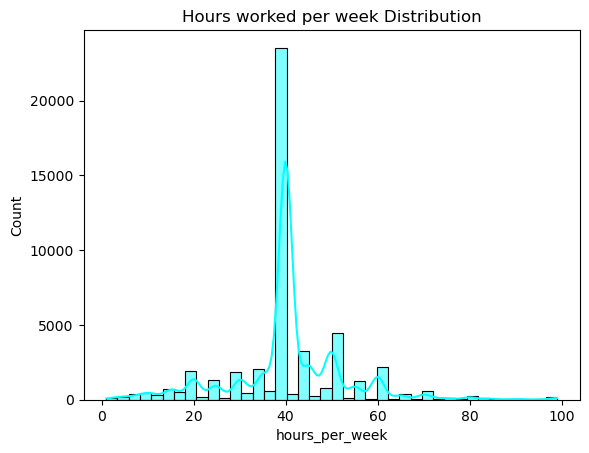

In [41]:
sns.histplot(data=df,x='hours_per_week',kde=True,bins=40,color='cyan')
plt.title('Hours worked per week Distribution')
plt.show()

In [42]:
print(f"Average Individual work about {df['hours_per_week'].mean():.1f} hours per week" )

Average Individual work about 40.4 hours per week


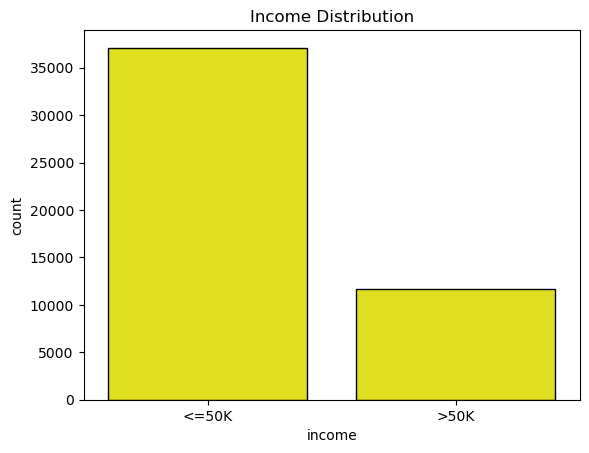

In [46]:
sns.countplot(x=df['income'],color='yellow',edgecolor='black')
plt.title('Income Distribution')
plt.show()

In [51]:
print(f"Most peoples have an annual income of 50K or less")

Most peoples have an annual income of 50K or less


In [52]:
df.head()

,age,workclass,fnlwgt,education,education_num,martial_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


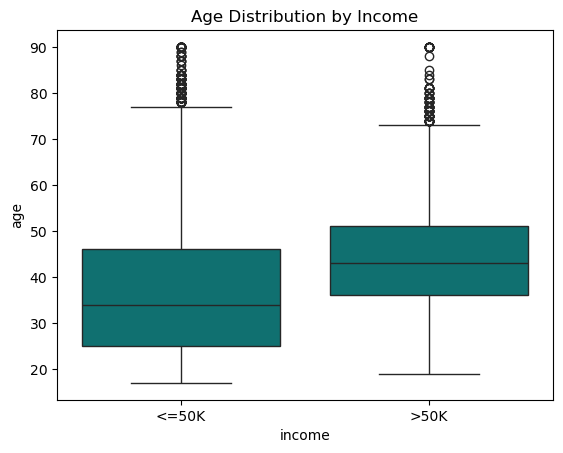

In [58]:
sns.boxplot(data=df,y='age',x='income',color='teal')
plt.title('Age Distribution by Income')
plt.show()

In [78]:
print(f"Average age of people income less than 50 k is {df.groupby('income')['age'].mean()['<=50K']:.2f} year")
print(f"Average age of people income above than 50 k is {df.groupby('income')['age'].mean()['>50K']:.2f} year")

Average age of people income less than 50 k is 36.88 year
Average age of people income above than 50 k is 44.28 year


In [112]:
income_wc=(pd.crosstab(df['workclass'],df['income'],normalize='index')*100).round(2)
income_wc

income,<=50K,>50K
workclass,,
Federal-gov,60.82,39.18
Local-gov,70.44,29.56
Never-worked,100.00,0.00
Private,79.14,20.86
Self-emp-inc,44.63,55.37
Self-emp-not-inc,72.11,27.89
State-gov,73.25,26.75
Without-pay,90.48,9.52


In [113]:
print(f"Individuals in the Self-emp-inc workclass have the highest percentage of annual incomes above $50K ({income_wc.loc['Self-emp-inc', '>50K']}%).")

Individuals in the Self-emp-inc workclass have the highest percentage of annual incomes above $50K (55.37%).


In [116]:
income_edu=(pd.crosstab(df['education'],df['income'],normalize='index')*100).round(2)
income_edu

income,<=50K,>50K
education,,
10th,93.74,6.26
11th,94.92,5.08
12th,92.67,7.33
1st-4th,96.73,3.27
5th-6th,94.67,5.33
7th-8th,93.50,6.50
9th,94.58,5.42
Assoc-acdm,74.20,25.80
Assoc-voc,74.66,25.34


In [119]:
print(f"Individual with education level of Prof-school has the highest percenatge of annual income above 50k ({income_edu.loc['Prof-school','>50K']}%)")

Individual with education level of Prof-school has the highest percenatge of annual income above 50k (73.98%)


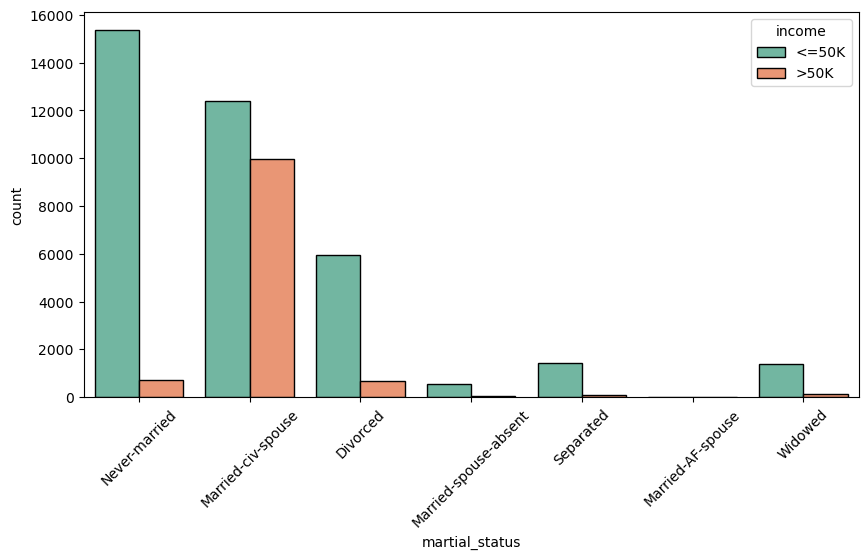

In [130]:
plt.figure(figsize=(10,5))
sns.countplot(data=df,x='martial_status',hue='income',palette='Set2',edgecolor='black')
plt.xticks(rotation=45)
plt.show()

In [132]:
income_martial=(pd.crosstab(df['martial_status'],df['income'],normalize='index')*100).round(2)
income_martial

income,<=50K,>50K
martial_status,,
Divorced,89.88,10.12
Married-AF-spouse,62.16,37.84
Married-civ-spouse,55.39,44.61
Married-spouse-absent,90.75,9.25
Never-married,95.44,4.56
Separated,93.53,6.47
Widowed,91.57,8.43


In [135]:
print(f"People with martial_status of Married-civ-spouse has the highest percentage of annual income above 50k ({income_martial.loc['Married-civ-spouse','>50K']}%)")

People with martial_status of Married-civ-spouse has the highest percentage of annual income above 50k (44.61%)


In [137]:
income_occ=(pd.crosstab(df['occupation'],df['income'],normalize='index')*100).round(2)
income_occ

income,<=50K,>50K
occupation,,
Adm-clerical,86.30,13.70
Armed-Forces,66.67,33.33
Craft-repair,77.35,22.65
Exec-managerial,52.22,47.78
Farming-fishing,88.35,11.65
Handlers-cleaners,93.34,6.66
Machine-op-inspct,87.70,12.30
Other-service,95.85,4.15
Priv-house-serv,98.75,1.25
